# SIM 1000s — Analysis

Simulations 1000–1009: hexagonal random foam compressed at 10 internal pressure levels.

Pressure series: `P = [0.0] + [0.004 × √2^i for i in 0..8]`

**Plots**
1. Reaction force vs displacement — all sims
2. Factor `f` (global efficiency tension / compression) vs displacement — all sims
3. Shear mean vs displacement — all sims

In [7]:
import sys, os, pickle, json
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('..'))

RESULTS_DIR = '../I001_Results'
OBJ_DIR     = '../I001_Results/OBJ_files'
SIMS        = list(range(1000, 1010))


In [8]:
def load_pkl(path):
    if not os.path.exists(path):
        return None
    with open(path, 'rb') as f:
        return pickle.load(f)

def get_pressure(sim):
    path = os.path.join(OBJ_DIR, f'SIM_{sim:03d}.json')
    if not os.path.exists(path):
        return None
    with open(path) as f:
        d = json.load(f)
    for step in d.get('steps', []):
        pb = step.get('Pressure_BC', 0)
        if pb:
            return float(pb)
    return 0.0


In [9]:
PRESSURES = {sim: get_pressure(sim) for sim in SIMS}
print({sim: f'{p:.6f} MPa' for sim, p in PRESSURES.items()})


{1000: '0.000000 MPa', 1001: '0.040000 MPa', 1002: '0.056569 MPa', 1003: '0.080000 MPa', 1004: '0.113137 MPa', 1005: '0.160000 MPa', 1006: '0.226274 MPa', 1007: '0.320000 MPa', 1008: '0.452548 MPa', 1009: '0.640000 MPa'}


## Plot 1 — Reaction force vs displacement

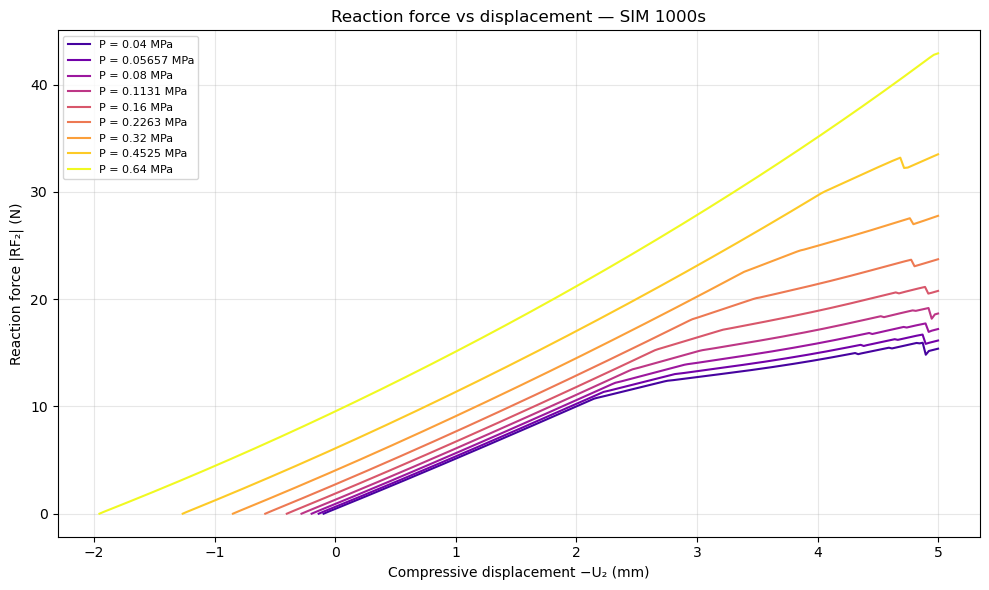

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
cmap = plt.get_cmap('plasma', len(SIMS))

for idx, sim in enumerate(SIMS):
    a2 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
    if a2 is None:
        continue
    # U2 at PERN-9999997 is signed (positive = pressure-induced expansion in
    # Step-0, ramping down through 0 to the imposed compression in Step-1) and
    # is monotonically decreasing over time. Negate (don't abs!) to get a
    # monotonically increasing compressive-displacement axis.
    displ = -np.array(a2['U2']['PERN-9999997'])
    rf2   = np.abs(np.array(a2['RF2']['PERN-9999997']))
    del a2

    ax.plot(displ, rf2, color=cmap(idx), label=f'P = {PRESSURES[sim]:.4g} MPa')

ax.set_xlabel('Compressive displacement −U₂ (mm)')
ax.set_ylabel('Reaction force |RF₂| (N)')
ax.set_title('Reaction force vs displacement — SIM 1000s')
ax.legend(loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## Plot 2 — Factor `f` (tension / compression efficiency) vs displacement

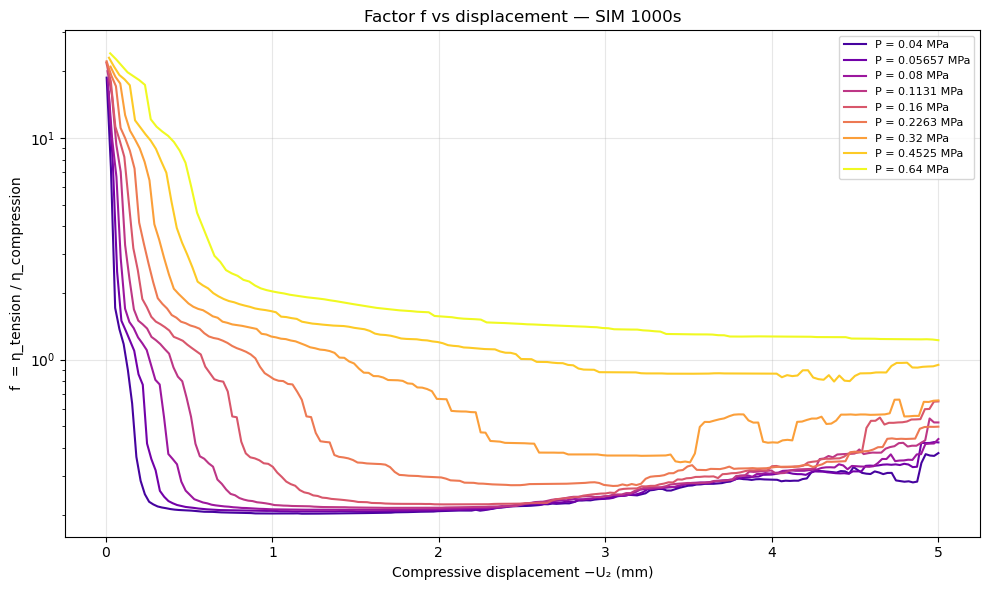

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
cmap = plt.get_cmap('plasma', len(SIMS))

for idx, sim in enumerate(SIMS):
    a2 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
    i3 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_I3_BFS_3002.pkl'))
    if a2 is None or i3 is None:
        del a2, i3
        continue
    displ = -np.array(a2['U2']['PERN-9999997'])
    ef_t  = np.array(i3['global_ef_t'], dtype=float)
    ef_c  = np.array(i3['global_ef_c'], dtype=float)
    del a2, i3

    with np.errstate(divide='ignore', invalid='ignore'):
        f = np.where(ef_c != 0, ef_t / ef_c, np.nan)
    del ef_t, ef_c

    mask = ~np.isnan(f) & (displ > 0)
    ax.plot(displ[mask], f[mask], color=cmap(idx), label=f'P = {PRESSURES[sim]:.4g} MPa')

ax.set_xlabel('Compressive displacement −U₂ (mm)')
ax.set_ylabel('f  = η_tension / η_compression')
ax.set_title('Factor f vs displacement — SIM 1000s')
ax.set_yscale('log')
ax.legend(loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## Plot 3 — Shear mean vs displacement

/tmp/ipykernel_3755045/48348346.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='best', fontsize=8)


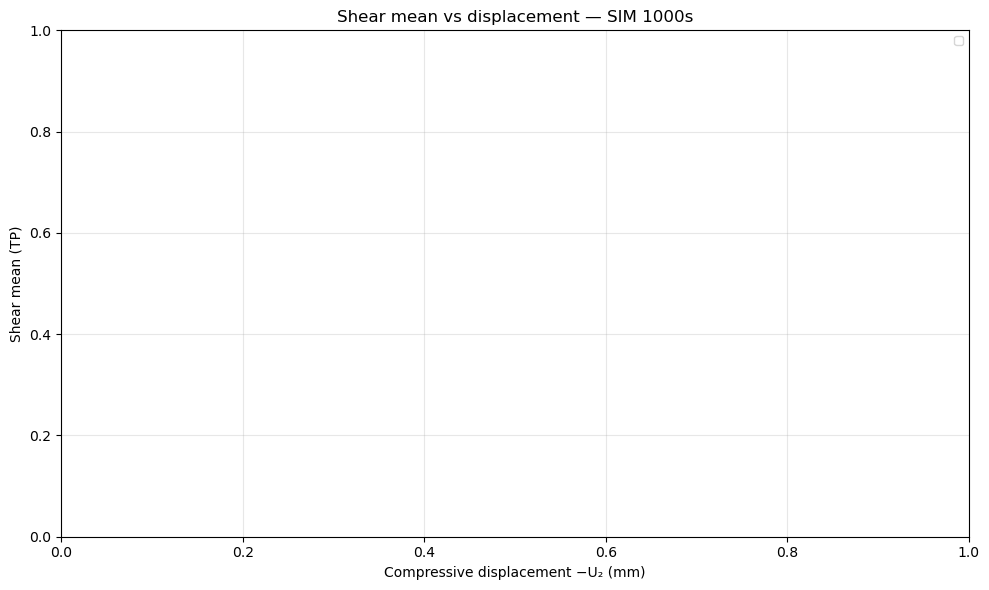

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
cmap = plt.get_cmap('plasma', len(SIMS))

for idx, sim in enumerate(SIMS):
    a2   = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
    tp2l = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_TP2_L.pkl'))
    if a2 is None or tp2l is None:
        del a2, tp2l
        continue
    displ      = -np.array(a2['U2']['PERN-9999997'])
    shear_mean = np.array(tp2l['shear_mean'])
    del a2, tp2l

    ax.plot(displ, shear_mean, color=cmap(idx), label=f'P = {PRESSURES[sim]:.4g} MPa')

ax.set_xlabel('Compressive displacement −U₂ (mm)')
ax.set_ylabel('Shear mean (TP)')
ax.set_title('Shear mean vs displacement — SIM 1000s')
ax.legend(loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()
